In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [2]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim_model: int, max_period: int = 100):
        super().__init__()
        self.dim_model = dim_model
        self.max_period = max_period

        self.linear1 = nn.Linear(dim_model, dim_model * 4)
        self.linear2 = nn.Linear(dim_model * 4, dim_model)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.unsqueeze(-1).float()  # (batch_size,) -> (batch_size, 1)

        half_dim = self.dim_model // 2
        frequencies = torch.exp(
            torch.arange(half_dim, device=t.device)
            * (-np.log(self.max_period / half_dim))
        )

        # (batch_size, 1) * (1, half_dim) -> (batch_size, half_dim)
        args = t * frequencies.unsqueeze(0)

        sin_embed = torch.sin(args)
        cos_embed = torch.cos(args)

        time_embed = torch.cat([sin_embed, cos_embed], dim=-1)

        x = self.linear1(time_embed)
        x = F.silu(x)
        x = self.linear2(x)

        return x

In [3]:
time_embed_module = TimeEmbedding(dim_model=128).to(device)
sample_times = torch.tensor([0, 100, 500, 999], device=device)  # Example time steps
embedded_times = time_embed_module(sample_times)
print(f"Time Embedding shape: {embedded_times.shape}")  # Expected shape: (4, 128)


Time Embedding shape: torch.Size([4, 128])


In [4]:
class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        time_embedding_dim: int,
        num_groups: int = 32,
    ):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=num_groups, num_channels=in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.time_mlp = nn.Linear(time_embedding_dim, 2 * out_channels)

        self.norm2 = nn.GroupNorm(num_groups=num_groups, num_channels=out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(
                in_channels, out_channels, kernel_size=1, stride=1
            )
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x: torch.Tensor, t_embed: torch.Tensor) -> torch.Tensor:
        shortcut = x

        h = x
        h = self.norm1(h)
        h = self.act1(h)
        h = self.conv1(h)

        time_scale_shift = self.time_mlp(t_embed)
        scale, shift = torch.chunk(time_scale_shift, 2, dim=1)

        scale = scale.unsqueeze(-1).unsqueeze(-1)
        shift = shift.unsqueeze(-1).unsqueeze(-1)

        h = h * (1 + scale) + shift

        h = self.norm2(h)
        h = self.act2(h)
        h = self.conv2(h)

        y = h + self.residual_conv(shortcut)

        return y

In [5]:
res_block = ResidualBlock(3, 16, 3, 1)

test_batch = torch.randn(2, 3, 64, 64)
t_embed = torch.randn(2, 3)

res_block(test_batch, t_embed).shape

torch.Size([2, 16, 64, 64])

In [6]:
class DownsampleBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)

In [7]:
downsample_block = DownsampleBlock(3)
downsample_block(test_batch).shape

torch.Size([2, 3, 32, 32])

In [8]:
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.conv_transpose = nn.ConvTranspose2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_transpose(x)

In [9]:
upsample_block = UpsampleBlock(3, 3)
upsample_block(test_batch).shape

torch.Size([2, 3, 128, 128])

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, channels: int, num_groups: int = 32):
        super().__init__()

        self.channels = channels

        self.norm = nn.GroupNorm(num_groups=num_groups, num_channels=channels)

        self.conv_q = nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0)
        self.conv_k = nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0)
        self.conv_v = nn.Conv2d(channels, channels, kernel_size=1, stride=1, padding=0)

        self.conv_out = nn.Conv2d(
            channels, channels, kernel_size=1, stride=1, padding=0
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x

        batch_size, channels, height, width = x.shape

        h = self.norm(x)

        q = self.conv_q(h)
        k = self.conv_k(h)
        v = self.conv_v(h)

        num_pixels = height * width
        q = q.view(batch_size, channels, num_pixels).permute(0, 2, 1)
        k = k.view(batch_size, channels, num_pixels).permute(0, 2, 1)
        v = v.view(batch_size, channels, num_pixels).permute(0, 2, 1)
        # (batch_size, num_pixels, channels)

        scores = q @ k.transpose(-2, -1)

        scaling_factor = self.channels**0.5
        scores = scores / scaling_factor

        attention_weights = F.softmax(scores, dim=-1)

        attention_output = attention_weights @ v

        attention_output = attention_output.permute(0, 2, 1).view(
            batch_size, channels, height, width
        )

        y = self.conv_out(attention_output)

        y = y + shortcut

        return y


In [11]:
channels = 64

H, W = 16, 16

attention_block = AttentionBlock(channels).to(device)

dummy_input = torch.randn(4, channels, H, W, device=device)

with torch.no_grad():
    output = attention_block(dummy_input)

print(f"Input shape of AttentionBlock: {dummy_input.shape}")
print(f"Output shape of AttentionBlock: {output.shape}")


Input shape of AttentionBlock: torch.Size([4, 64, 16, 16])
Output shape of AttentionBlock: torch.Size([4, 64, 16, 16])


In [12]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        model_channels=64,
        channel_mults=(1, 2, 4, 8),
        num_res_blocks=2,
        attention_resolutions=(16, 8),
        time_embedding_dim=None,
        num_groups=32,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.model_channels = model_channels
        self.channel_mults = channel_mults
        self.num_res_blocks = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.num_groups = num_groups

        num_stages = len(channel_mults)
        self.num_stages = num_stages

        if time_embedding_dim is None:
            time_embedding_dim = model_channels * 4
        self.time_embedding_dim = time_embedding_dim

        self.time_embedding = TimeEmbedding(dim_model=time_embedding_dim)

        self.initial_conv = nn.Conv2d(
            in_channels, model_channels, kernel_size=3, stride=1, padding=1
        )

        self.down_blocks = nn.ModuleList()
        down_channels_out = []
        current_channels = model_channels

        for i in range(num_stages):
            stage_out_channels = model_channels * channel_mults[i]
            stage_blocks = nn.ModuleList()

            for _ in range(num_res_blocks):
                stage_blocks.append(
                    ResidualBlock(
                        current_channels,
                        stage_out_channels,
                        time_embedding_dim,
                        num_groups,
                    )
                )

                current_channels = stage_out_channels

            current_resolution = 32 // (2**i)
            if current_resolution in attention_resolutions:
                stage_blocks.append(AttentionBlock(current_channels, num_groups))

            down_channels_out.append(current_channels)

            stage_blocks.append(DownsampleBlock(current_channels))

            self.down_blocks.append(stage_blocks)

        bottleneck_channels = current_channels * 2

        self.mid_block = nn.ModuleList(
            [
                ResidualBlock(
                    current_channels,
                    bottleneck_channels,
                    time_embedding_dim,
                    num_groups,
                ),
                AttentionBlock(bottleneck_channels, num_groups),
                ResidualBlock(
                    bottleneck_channels,
                    bottleneck_channels,
                    time_embedding_dim,
                    num_groups,
                ),
            ]
        )

        current_channels = bottleneck_channels

        self.up_blocks = nn.ModuleList()

        for i in reversed(range(num_stages)):
            stage_out_channels = down_channels_out[i]

            stage_blocks = nn.ModuleList()

            stage_blocks.append(UpsampleBlock(current_channels, stage_out_channels))

            for _ in range(num_res_blocks + 1):
                stage_blocks.append(
                    ResidualBlock(
                        current_channels,
                        stage_out_channels,
                        time_embedding_dim,
                        num_groups,
                    )
                )

                current_channels = stage_out_channels

            current_resolution = 32 // (2**i)
            if current_resolution in attention_resolutions:
                stage_blocks.append(AttentionBlock(current_channels, num_groups))

            self.up_blocks.append(stage_blocks)

        self.final_norm = nn.GroupNorm(num_groups, current_channels)
        self.final_act = nn.SiLU()
        self.final_conv = nn.Conv2d(
            current_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_embed = self.time_embedding(t)

        x = self.initial_conv(x)

        skip_connections = []

        for i in range(self.num_stages):
            stage_blocks = self.down_blocks[i]
            stage_out = x

            num_blocks_in_stage = len(stage_blocks)

            for j in range(num_blocks_in_stage - 1):
                block = stage_blocks[j]
                if isinstance(block, ResidualBlock):
                    stage_out = block(stage_out, t_embed)
                elif isinstance(block, AttentionBlock):
                    stage_out = block(stage_out)

            skip_connections.append(stage_out)

            downsample_block = stage_blocks[-1]
            x = downsample_block(stage_out)

        mid_out = x

        for block in self.mid_block:
            if isinstance(block, ResidualBlock):
                mid_out = block(mid_out, t_embed)
            elif isinstance(block, AttentionBlock):
                mid_out = block(mid_out)

        x = mid_out

        for i in range(self.num_stages):
            decoder_stage_blocks = self.up_blocks[i]
            encoder_stage_idx = self.num_stages - 1 - i

            skip_features = skip_connections[encoder_stage_idx]

            upsample_block = decoder_stage_blocks[0]
            x = upsample_block(x)
            remaining_blocks = decoder_stage_blocks[1:]

            x = torch.cat([x, skip_features], dim=1)

            for block in remaining_blocks:
                if isinstance(block, ResidualBlock):
                    x = block(x, t_embed)
                elif isinstance(block, AttentionBlock):
                    x = block(x)

        x = self.final_norm(x)
        x = self.final_act(x)
        x = self.final_conv(x)

        return x


In [13]:
unet = UNet(
    model_channels=32, channel_mults=(1, 2, 4), num_res_blocks=1, num_groups=32
).to(device)

test_batch = torch.randn(2, 3, 32, 32, device=device)
sample_times = torch.tensor([0, 100], device=device)  # Example time steps
unet(test_batch, sample_times).shape  # Expected shape: (2, 3, 32, 32)

torch.Size([2, 3, 32, 32])

In [14]:
total_params = sum(param.numel() for param in unet.parameters())
total_params


4870659

In [15]:
def cosine_beta_schedule(timesteps: int, s: float = 0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.9999)


def sample_by_t(a: torch.Tensor, t: torch.Tensor, x_shape: torch.Size):
    batch_size = t.shape[0]
    # out = a.gather(-1, t.cpu()).to(t.device)
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def sample_q(
    x0: torch.Tensor,
    t: torch.Tensor,
    sqrt_alphas_bar_t: torch.Tensor,
    sqrt_1_minus_alphas_bar_t: torch.Tensor,
    noise=None,
):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alphas_bar_t_sampled = sample_by_t(sqrt_alphas_bar_t, t, x0.shape)
    sqrt_1_minus_alphas_bar_t_sampled = sample_by_t(
        sqrt_1_minus_alphas_bar_t, t, x0.shape
    )

    x_t = sqrt_alphas_bar_t_sampled * x0 + sqrt_1_minus_alphas_bar_t_sampled * noise
    return x_t, noise


num_timesteps = 1000
betas_t = cosine_beta_schedule(num_timesteps)

# alphas_t = 1.0 - betas_t
# alphas_bar_t = torch.cumprod(alphas_t, dim=0)

# sqrt_alphas_bar_t = torch.sqrt(alphas_bar_t)
# sqrt_1_minus_alphas_bar_t = torch.sqrt(1.0 - alphas_bar_t)

In [16]:
import lightning as L


class DiffusionUNetModule(L.LightningModule):
    def __init__(self, unet_params, optimizer_params, timesteps):
        super().__init__()

        self.save_hyperparameters()

        self.unet = UNet(**self.hparams.unet_params)

        self.timesteps = self.hparams.timesteps

        betas_t = cosine_beta_schedule(timesteps=self.timesteps)
        alphas_t = 1.0 - betas_t
        alphas_bar_t = torch.cumprod(alphas_t, dim=0)
        sqrt_alphas_bar_t = torch.sqrt(alphas_bar_t)
        sqrt_1_minus_alphas_bar_t = torch.sqrt(1.0 - alphas_bar_t)

        self.register_buffer("betas_t", betas_t)
        self.register_buffer("alphas_t", alphas_t)
        self.register_buffer("alphas_bar_t", alphas_bar_t)
        self.register_buffer("sqrt_alphas_bar_t", sqrt_alphas_bar_t)
        self.register_buffer("sqrt_1_minus_alphas_bar_t", sqrt_1_minus_alphas_bar_t)

        self.criterion = nn.MSELoss()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        return self.unet(x, t)

    def training_step(self, batch: torch.Tensor, batch_idx: int):
        images = batch[0]

        batch_size = images.shape[0]

        t = torch.randint(
            low=0, high=self.timesteps, size=(batch_size,), device=images.device
        ).long()

        x_t, noise = sample_q(
            images, t, self.sqrt_alphas_bar_t, self.sqrt_1_minus_alphas_bar_t
        )

        predicted_noise = self(x_t, t)

        loss = self.criterion(predicted_noise, noise)

        self.log("train/loss", loss, prog_bar=True)

        return loss

    def validation_step(self, batch: torch.Tensor, batch_idx: int):
        images = batch[0]

        batch_size = images.shape[0]

        t = torch.randint(
            low=0, high=self.timesteps, size=(batch_size,), device=images.device
        ).long()

        x_t, noise = sample_q(
            images, t, self.sqrt_alphas_bar_t, self.sqrt_1_minus_alphas_bar_t
        )

        predicted_noise = self(x_t, t)

        loss = self.criterion(predicted_noise, noise)

        self.log("val/loss", loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), **self.hparams.optimizer_params
        )
        return optimizer

In [17]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

data_root_folder = "data"
image_size = 32

batch_size = 128

data_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

full_dataset = ImageFolder(root=data_root_folder, transform=data_transform)

train_ratio = 0.8
val_ratio = 1.0 - train_ratio

train_size = int(train_ratio * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True
)

In [18]:
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import WandbLogger
import wandb


wandb_logger = WandbLogger(project="trafic-signs-generation")

unet_params = {
    "in_channels": 3,
    "out_channels": 3,
    "model_channels": 64,
    "channel_mults": (1, 2, 4),
    "num_res_blocks": 2,
    "attention_resolutions": (16, 8),
    "num_groups": 32,
}

optimizer_params = {"lr": 5e-5}

total_timesteps = 1000

model = DiffusionUNetModule(unet_params, optimizer_params, total_timesteps)

checkpoint_cb = ModelCheckpoint(
    monitor="val/loss",
    mode="min",
    save_top_k=1,
    filename="best-model-{epoch:02d}",
)
early_stop = EarlyStopping(monitor="val/loss", patience=3, mode="min")

trainer = Trainer(
    max_epochs=2,
    accelerator="mps",
    callbacks=[checkpoint_cb, early_stop],
    log_every_n_steps=10,
    logger=wandb_logger,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

wandb.finish()


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: danielmachniak423 (danielmachniak423-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | unet      | UNet    | 23.0 M | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
23.0 M    Trainable params
0         Non-trainable params
23.0 M    Total params
92.045    Total estimated model params size (MB)
213       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/daniel/Studia/Semestr_6/SSNE/projekt_4/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/daniel/Studia/Semestr_6/SSNE/projekt_4/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/daniel/Studia/Semestr_6/SSNE/projekt_4/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁████████████████████
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
val/loss,█▁
epoch,1
train/loss,0.0955
trainer/global_step,491
val/loss,0.09592


Rozpoczynanie generowania obrazów...
Generowanie zakończone.


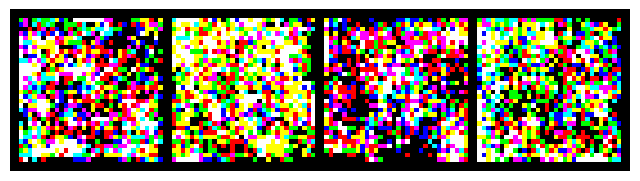

In [19]:
import torchvision.utils as vutils # Przydatne do tworzenia siatki obrazów
import matplotlib.pyplot as plt  


model.eval() # Ustaw model w tryb ewaluacji (ważne!)


# --- 2. Zaimplementuj proces samplowania (pętla odszumiająca) ---

def sample_image(model, timesteps: int, img_shape: tuple, device: torch.device):
    """
    Przeprowadza proces samplowania (odszumiania) w celu wygenerowania obrazów.

    Args:
        model: Wytrenowany model DiffusionUNetModule.
        timesteps: Całkowita liczba kroków dyfuzji (T).
        img_shape: Kształt tensora do wygenerowania (np. (ilość_obrazów, kanały, H, W)).
        device: Urządzenie, na którym ma być przeprowadzane samplowanie.

    Returns:
        Tensor z wygenerowanymi obrazami (w zakresie [-1, 1]).
    """
    # Rozpocznij od czystego szumu o docelowym kształcie obrazu
    x_t = torch.randn(img_shape, device=device)

    # Upewnij się, że model jest w trybie ewaluacji i na odpowiednim urządzeniu
    model.eval()
    model.to(device)

    # Wyłącz obliczanie gradientów podczas samplowania (nie są potrzebne)
    with torch.no_grad():
        # Pętla odszumiająca od T do 1
        for t in range(timesteps, 0, -1):
            # Utwórz tensor kroku czasowego dla tego batcha
            # Musi mieć kształt (batch_size,) i typ long
            t_tensor = torch.full((img_shape[0],), t, device=device, dtype=torch.long)

            # --- Wykorzystaj model do przewidzenia szumu w bieżącym kroku t ---
            # predicted_noise = model(x_t, t_tensor) # Wywołaj metodę forward modelu

            # UWAGA: Jeśli Twoja klasa DiffusionUNetModule ma metodę forward(x, t),
            # to 'model(x_t, t_tensor)' jest prawidłowe.
            # Jeśli Twoja klasa ma forward(x, t, conditioning_info), musisz podać info.
            # Jeśli Twoja klasa UNet ma forward(x, t, conditioning_info), a LightningModule.forward tylko (x, t),
            # to trzeba to dostosować w forward LightningModule.

            # Przyjmujemy, że model.forward(x_t, t_tensor) działa poprawnie i zwraca predykcję szumu
            predicted_noise = model(x_t, t_tensor)


            # --- Oblicz następny, mniej zaszumiony krok x_{t-1} ---
            # Potrzebujemy wartości harmonogramu dla kroku t.
            # Bufory w modelu (np. model.betas_t) są indeksowane od 0 do T-1.
            # W pętli t idzie od T do 1. Wartość dla kroku t znajduje się pod indeksem t-1.
            # Użyj funkcji extract/sample_by_t, która wie jak pobrać wartość dla indexu t-1 z tensora
            # Jeśli extract/sample_by_t jest metodą w klasie Module, użyj model.extract()

            # Upewnij się, że extract/sample_by_t poprawnie pobiera wartość dla indexu t-1
            # Standardowa implementacja extract pobiera wartości dla batcha indeksów.
            # Możemy utworzyć batch indeksów [t-1, t-1, ..., t-1]
            t_minus_1_tensor = torch.full((img_shape[0],), t - 1, device=device, dtype=torch.long)


            # Pobierz odpowiednie wartości harmonogramu dla kroku t (index t-1 w buforach)
            # Użyj self.extract (jeśli jest metodą w Module) lub globalnego extract
            # Przyjmujemy, że extract działa poprawnie i zwraca broadcastowany tensor
            sqrt_alphas_t_t = sample_by_t(model.alphas_t, t_minus_1_tensor, x_t.shape).sqrt() # sqrt(alpha_t)
            betas_t_t = sample_by_t(model.betas_t, t_minus_1_tensor, x_t.shape) # beta_t
            sqrt_one_minus_alphas_bar_t_t = sample_by_t(model.sqrt_1_minus_alphas_bar_t, t_minus_1_tensor, x_t.shape) # sqrt(1 - alpha_bar_t)


            # Implementacja wzoru na krok odwrotny (deterministyczna, bez dodatkowego szumu):
            # x_{t-1} = 1/sqrt(alpha_t) * (x_t - beta_t / sqrt(1 - alpha_bar_t) * predicted_noise)
            # Ten wzór używa wartości harmonogramu DLA KROKU t (czyli index t-1 w tensorach),
            # aby przejść z x_t do x_{t-1}.

            # Oblicz średnią (mean) procesu odwrotnego
            mean = (x_t - betas_t_t * predicted_noise / sqrt_one_minus_alphas_bar_t_t) / sqrt_alphas_t_t

            # W samplingu deterministycznym x_{t-1} jest równe tej średniej
            # Jeśli chciałbyś samplowanie stochastyczne, dodałbyś tu jeszcze szum:
            # x_{t-1} = mean + sigma_t * z
            # gdzie sigma_t to np. sqrt(beta_t)
            # z = torch.randn_like(x_t) # Nowy szum dla każdego kroku i obrazu
            # sigma_t = extract(model.betas_t, t_minus_1_tensor, x_t.shape).sqrt()
            # x_t = mean + sigma_t * z


            # Nowym zaszumionym obrazem na następną iterację pętli (t-1) staje się obliczona średnia
            x_t = mean

        # Po zakończeniu pętli (gdy t dojdzie do 1), x_t będzie zawierać wygenerowane obrazy x_0
        generated_images = x_t

    return generated_images # Zwróć tensor z wygenerowanymi obrazami (w zakresie [-1, 1])


# --- 3. Odwróć normalizację obrazu ---

def unnormalize_image(tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    """
    Odwraza normalizację tensora obrazu z zakresu [-1, 1] do [0, 1].
    Przyjmuje tensor [B, C, H, W].
    """
    # Upewnij się, że mean i std są tensorami na tym samym urządzeniu co obraz
    mean = torch.tensor(mean, device=tensor.device).view(1, -1, 1, 1)
    std = torch.tensor(std, device=tensor.device).view(1, -1, 1, 1)
    unnormalized_tensor = tensor * std + mean
    # Ogranicz wartości do zakresu [0, 1] na wszelki wypadek
    unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)
    return unnormalized_tensor

# --- 4. Wyświetl obraz ---

def display_image_tensor(tensor):
    """
    Wyświetla tensor obrazu lub batcha obrazów (zakres [0, 1]).
    Przyjmuje tensor [B, C, H, W] lub [C, H, W].
    """
    # Jeśli to pojedynczy obraz [C, H, W], dodaj wymiar batcha [1, C, H, W]
    if tensor.ndim == 3:
        tensor = tensor.unsqueeze(0)

    # Użyj make_grid, aby ułożyć obrazy z batcha w siatkę
    # normalize=False, bo już odwróciliśmy normalizację do zakresu [0, 1]
    grid = vutils.make_grid(tensor, padding=2, normalize=False)

    # Konwertuj tensor do formatu NumPy [H, W, C]
    # .detach() odłącza od grafu obliczeń, .cpu() przenosi na CPU
    np_grid = grid.permute(1, 2, 0).cpu().numpy()

    # Wyświetl obraz za pomocą matplotlib
    plt.figure(figsize=(8, 8)) # Dostosuj rozmiar figury
    plt.imshow(np_grid)
    plt.axis('off') # Ukryj osie
    plt.show()


# --- PRZYKŁAD UŻYCIA PO TRENINGU ---

# >>> Po zakończeniu treningu i zapisaniu checkpointu <<<

# 1. Załaduj model (jak pokazano w sekcji "Załaduj wytrenowany model" powyżej)
# Np. model = DiffusionUNetModule.load_from_checkpoint(...) lub model.load_state_dict(...)
# Pamiętaj, aby przenieść model na urządzenie samplowania: model.to(device)

# 2. Zdefiniuj kształt obrazów, które chcesz wygenerować
# Np. wygeneruj 4 obrazy 3x32x32
generate_shape = (4, 3, 32, 32)

# 3. Wywołaj funkcję samplowania
print("Rozpoczynanie generowania obrazów...")
# Przekaż wytrenowany model, T, docelowy kształt i urządzenie
generated_images_tensor = sample_image(model, total_timesteps, generate_shape, device)
print("Generowanie zakończone.")

# 4. Odwróć normalizację wygenerowanych obrazów (z [-1, 1] do [0, 1])
unnormalized_images_tensor = unnormalize_image(generated_images_tensor)

# 5. Wyświetl wygenerowane obrazy
# Funkcja display_image_tensor przyjmuje tensor [B, C, H, W] w zakresie [0, 1]
display_image_tensor(unnormalized_images_tensor)
